In [8]:
import sys
sys.path.insert(0, '..')

import pandas as pd
from IPython.display import display, Markdown

from shared.plot_utilities import setup_notebook_display
from shared.regression_utilities import run_regression_suite, plot_regression_coefficient_heatmap
from nuke.utils.load_replay_data import (
    CONDITION_FACTORS,
    REPLAY_TAG_JOIN_KEYS,
    add_canonical_replay_model,
    add_condition_factor_columns,
    get_complete_replay_models,
    get_present_strategist_model_order,
    load_replay_data,
    prefixed_tier_columns,
    tier_source_columns,
)

setup_notebook_display()
df = load_replay_data()
df = add_canonical_replay_model(df)
df = add_condition_factor_columns(df)


✓ Loaded 37,440 rows from 96 files
  Conditions   : original, no-rationale, real-world, real-world-no-rationale, ethical, ethical-real-world, ethical-no-rationale, real-world-no-rationale-ethical
  Replay models: DeepSeek-V3.2, DeepSeek-V4, GLM-4.7, GLM-5.1, Gemma-4, Kimi-K2.5, Kimi-K2.6, MiniMax-M2.7, Mistral-Small-4, Qwen-3.5, Qwen-3.6-27B, gpt-oss-120b

  Rows per condition × replay model:
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                       DeepSeek-V3.2      DeepSeek-V4          GLM-4.7          GLM-5.1          Gemma-4        Kimi-K2.5        Kimi-K2.6     MiniMax-M2.7  Mistral-Small-4         Qwen-3.5     Qwen-3.6-27B     gpt-oss-120b            Total
  ────────────────────────────────────────────────────────────────────────────────────────

## Regressions: `replay_use_nuke_delta`

Three nested models (main effects â†’ condition interactions â†’ model Ã— condition) with game/player fixed effects and cluster-robust SEs.

Baseline: GPT-OSS-120B, has rationale, not real-world, not ethical

[main] replay_use_nuke_delta ~ no_rationale + real_world + ethical + C(replay_model_canonical, Treatment(reference="GPT-OSS-120B")) + C(_fe_group)
[interactions] replay_use_nuke_delta ~ no_rationale * real_world + no_rationale * ethical + real_world * ethical + C(replay_model_canonical, Treatment(reference="GPT-OSS-120B")) + C(_fe_group)
[model_x_condition] replay_use_nuke_delta ~ (no_rationale + real_world + ethical) * C(replay_model_canonical, Treatment(reference="GPT-OSS-120B")) + C(_fe_group)

Main Effects: Factor Contributions to Δ replay_use_nuke_delta
[baseline: GPT-OSS-120B, no no_rationale, no real_world, no ethical] SUMMARY

Statistically Significant Effects (p < 0.05):
----------------------------------------
  DeepSeek-3.2                   +15.914 [+13.799, +18.028] ***
  DeepSeek-4                     +6.639 [+4.434, +8.843] ***
  GLM-4.7                        +11.110 [+9.039, +13.181] ***
  GLM-5.1                        -4.198 [-6.302, -2.093] ***
  Gemma-4            

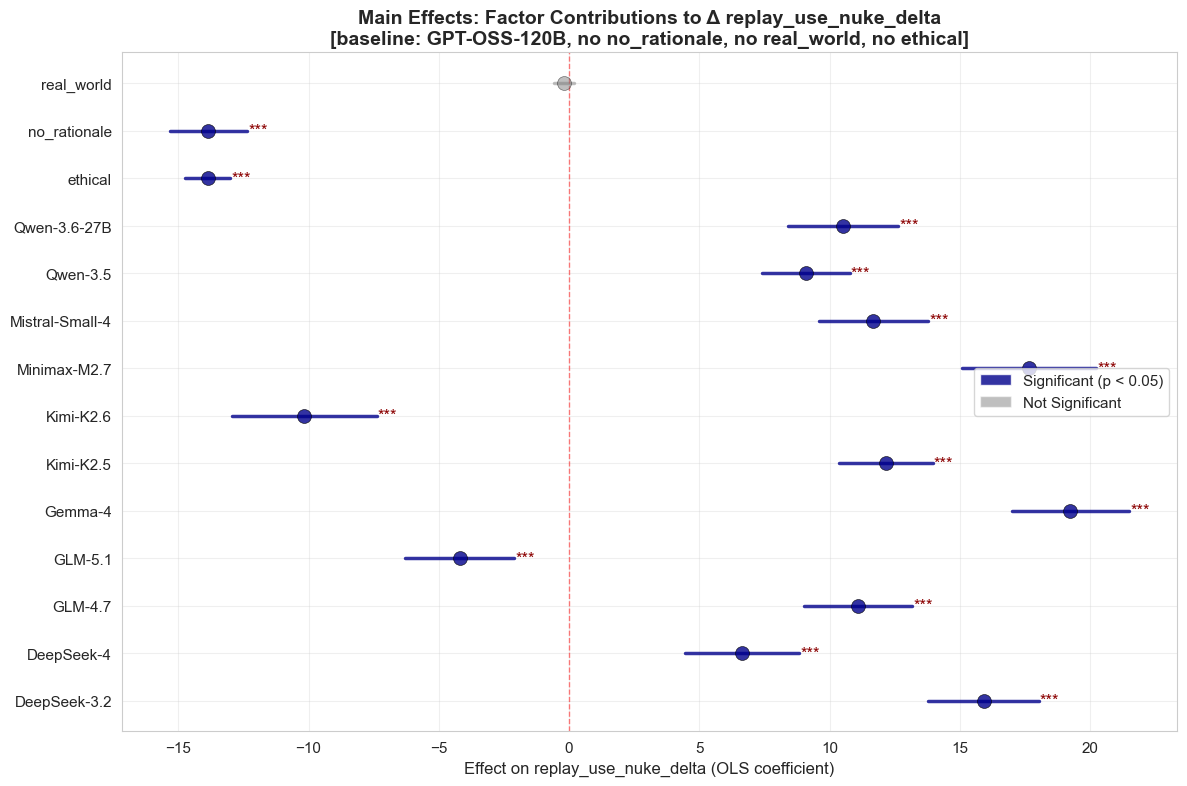

=== Main Effects (replay_use_nuke_delta) ===
                              OLS Regression Results                             
Dep. Variable:     replay_use_nuke_delta   R-squared:                       0.344
Model:                               OLS   Adj. R-squared:                  0.341
Method:                    Least Squares   F-statistic:                     112.9
Date:                   Sat, 09 May 2026   Prob (F-statistic):           3.46e-65
Time:                           10:47:19   Log-Likelihood:            -1.7044e+05
No. Observations:                  37440   AIC:                         3.412e+05
Df Residuals:                      37296   BIC:                         3.424e+05
Df Model:                            143                                         
Covariance Type:                 cluster                                         
R² = 0.3439, Adj R² = 0.3414, n = 37440, (cluster-robust SEs; FE: game_id, player_id)

With Interactions: Factor Contributions to Δ rep

c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 143, but rank is 14
  warnings.warn('covariance of constraints does not have full '


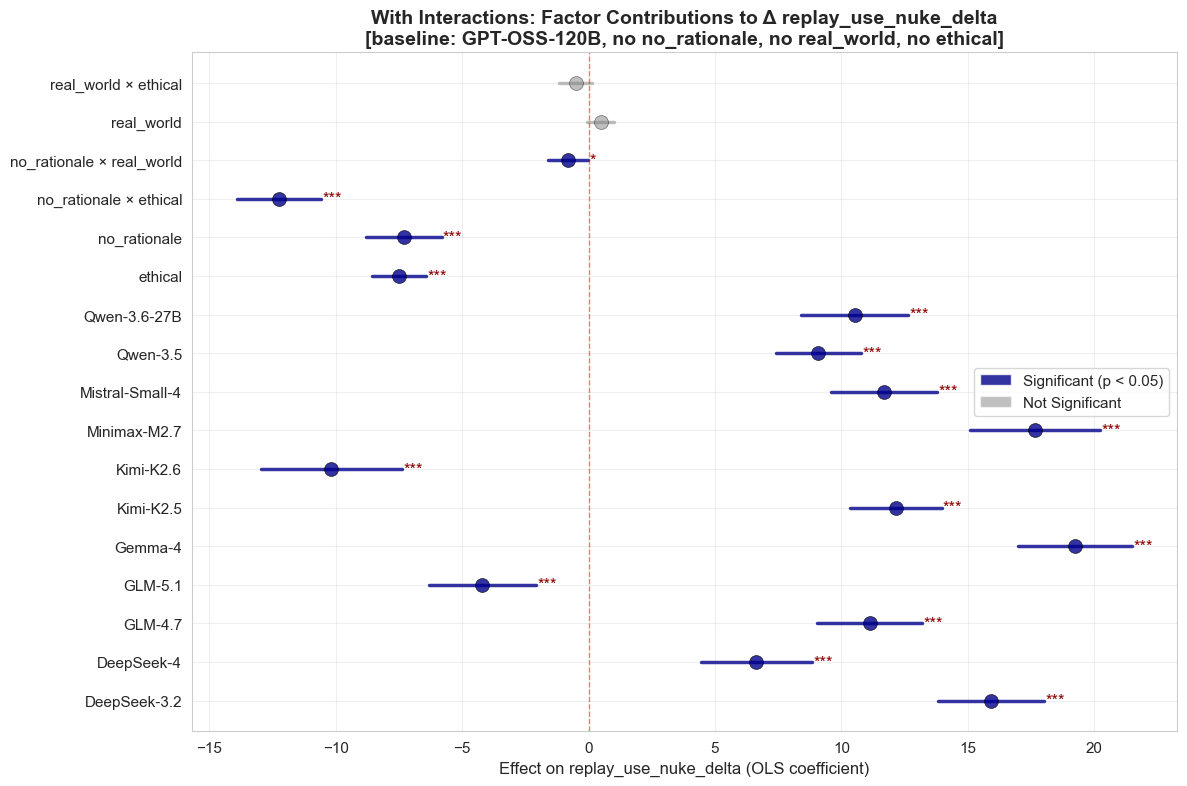


=== Condition Interactions (replay_use_nuke_delta) ===
                              OLS Regression Results                             
Dep. Variable:     replay_use_nuke_delta   R-squared:                       0.356
Model:                               OLS   Adj. R-squared:                  0.353
Method:                    Least Squares   F-statistic:                     94.24
Date:                   Sat, 09 May 2026   Prob (F-statistic):           4.42e-64
Time:                           10:47:20   Log-Likelihood:            -1.7010e+05
No. Observations:                  37440   AIC:                         3.405e+05
Df Residuals:                      37293   BIC:                         3.418e+05
Df Model:                            146                                         
Covariance Type:                 cluster                                         
R² = 0.3556, Adj R² = 0.3531, n = 37440, (cluster-robust SEs; FE: game_id, player_id)

=== Model x Condition (replay_use_nuk

c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 146, but rank is 17
  warnings.warn('covariance of constraints does not have full '
c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 176, but rank is 47
  warnings.warn('covariance of constraints does not have full '


In [9]:
GROUP_COLS = ['game_id', 'player_id']

_ = run_regression_suite(
    data=df,
    outcome='replay_use_nuke_delta',
    condition_factors=CONDITION_FACTORS,
    group_cols=GROUP_COLS,
)


## Regressions: `replay_nuke_delta`

Same regression suite for the nuke (launch) outcome.

[main] replay_nuke_delta ~ no_rationale + real_world + ethical + C(replay_model_canonical, Treatment(reference="GPT-OSS-120B")) + C(_fe_group)
[interactions] replay_nuke_delta ~ no_rationale * real_world + no_rationale * ethical + real_world * ethical + C(replay_model_canonical, Treatment(reference="GPT-OSS-120B")) + C(_fe_group)
[model_x_condition] replay_nuke_delta ~ (no_rationale + real_world + ethical) * C(replay_model_canonical, Treatment(reference="GPT-OSS-120B")) + C(_fe_group)

Main Effects: Factor Contributions to Δ replay_nuke_delta
[baseline: GPT-OSS-120B, no no_rationale, no real_world, no ethical] SUMMARY

Statistically Significant Effects (p < 0.05):
----------------------------------------
  DeepSeek-3.2                   +16.949 [+14.954, +18.943] ***
  DeepSeek-4                     +10.419 [+7.895, +12.943] ***
  GLM-4.7                        +14.700 [+12.655, +16.745] ***
  GLM-5.1                        +2.336 [+0.115, +4.557] *
  Gemma-4                        +20

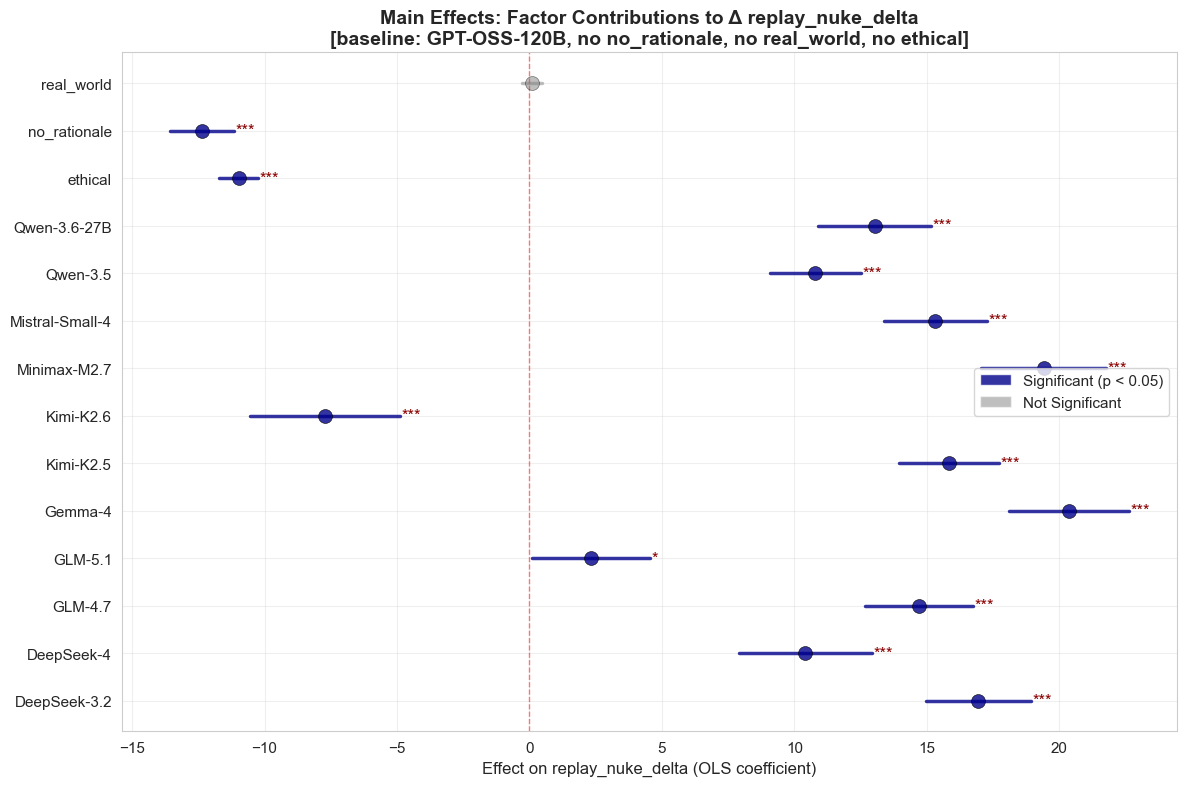

=== Main Effects (replay_nuke_delta) ===
                            OLS Regression Results                            
Dep. Variable:      replay_nuke_delta   R-squared:                       0.298
Model:                            OLS   Adj. R-squared:                  0.295
Method:                 Least Squares   F-statistic:                     97.56
Date:                Sat, 09 May 2026   Prob (F-statistic):           1.89e-61
Time:                        10:47:21   Log-Likelihood:            -1.6936e+05
No. Observations:               37440   AIC:                         3.390e+05
Df Residuals:                   37296   BIC:                         3.402e+05
Df Model:                         143                                         
Covariance Type:              cluster                                         
R² = 0.2982, Adj R² = 0.2955, n = 37440, (cluster-robust SEs; FE: game_id, player_id)

With Interactions: Factor Contributions to Δ replay_nuke_delta
[baseline: GPT-OSS-

c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 143, but rank is 14
  warnings.warn('covariance of constraints does not have full '


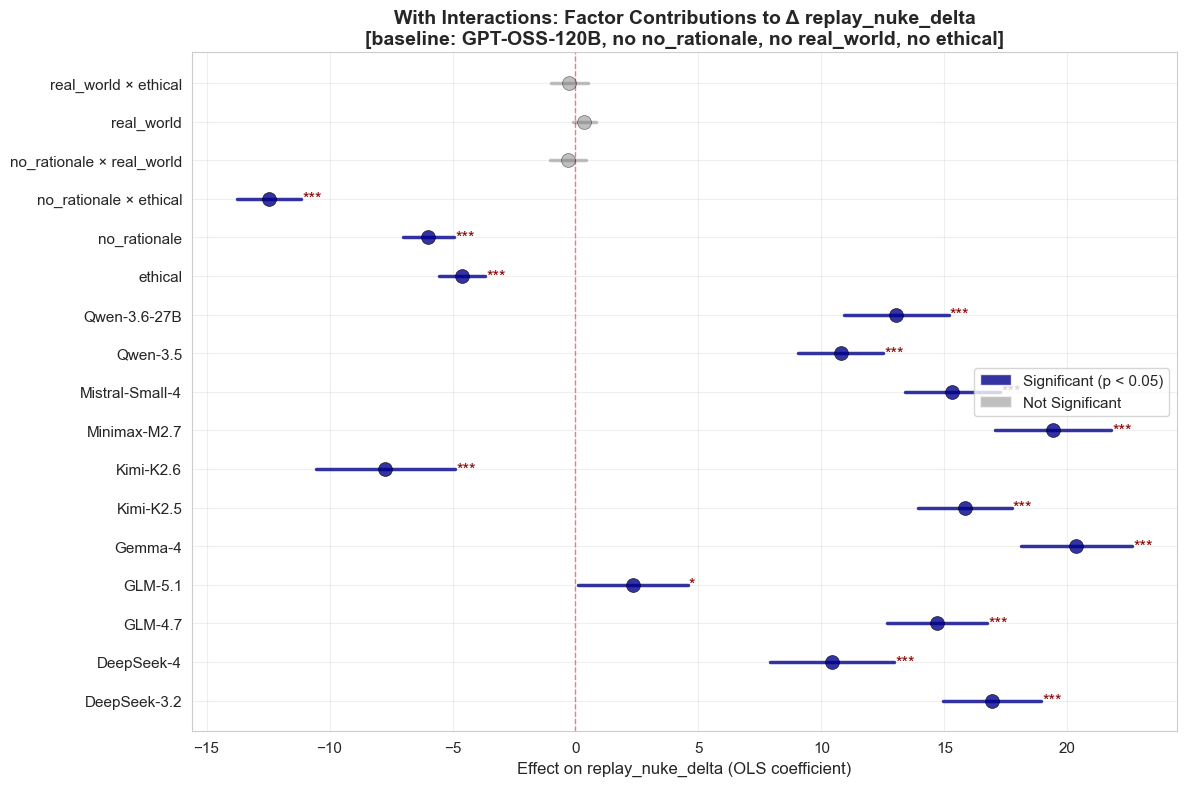

c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 146, but rank is 17
  warnings.warn('covariance of constraints does not have full '



=== Condition Interactions (replay_nuke_delta) ===
                            OLS Regression Results                            
Dep. Variable:      replay_nuke_delta   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     96.39
Date:                Sat, 09 May 2026   Prob (F-statistic):           1.16e-64
Time:                        10:47:22   Log-Likelihood:            -1.6899e+05
No. Observations:               37440   AIC:                         3.383e+05
Df Residuals:                   37293   BIC:                         3.395e+05
Df Model:                         146                                         
Covariance Type:              cluster                                         
R² = 0.3119, Adj R² = 0.3092, n = 37440, (cluster-robust SEs; FE: game_id, player_id)

=== Model x Condition (replay_nuke_delta) ===
                         

c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 176, but rank is 47
  warnings.warn('covariance of constraints does not have full '


In [10]:
_ = run_regression_suite(
    data=df,
    outcome='replay_nuke_delta',
    condition_factors=CONDITION_FACTORS,
    group_cols=GROUP_COLS,
)

## Per-Model Factor Contributions

Separate OLS regressions per model with pairwise interactions:
`outcome ~ no_rationale * real_world + no_rationale * ethical + real_world * ethical`
with cluster-robust SEs.

Left panel shows main-effect and interaction coefficients with significance stars.
Right panel shows per-model RÂ².

### replay_use_nuke_delta

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:408: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


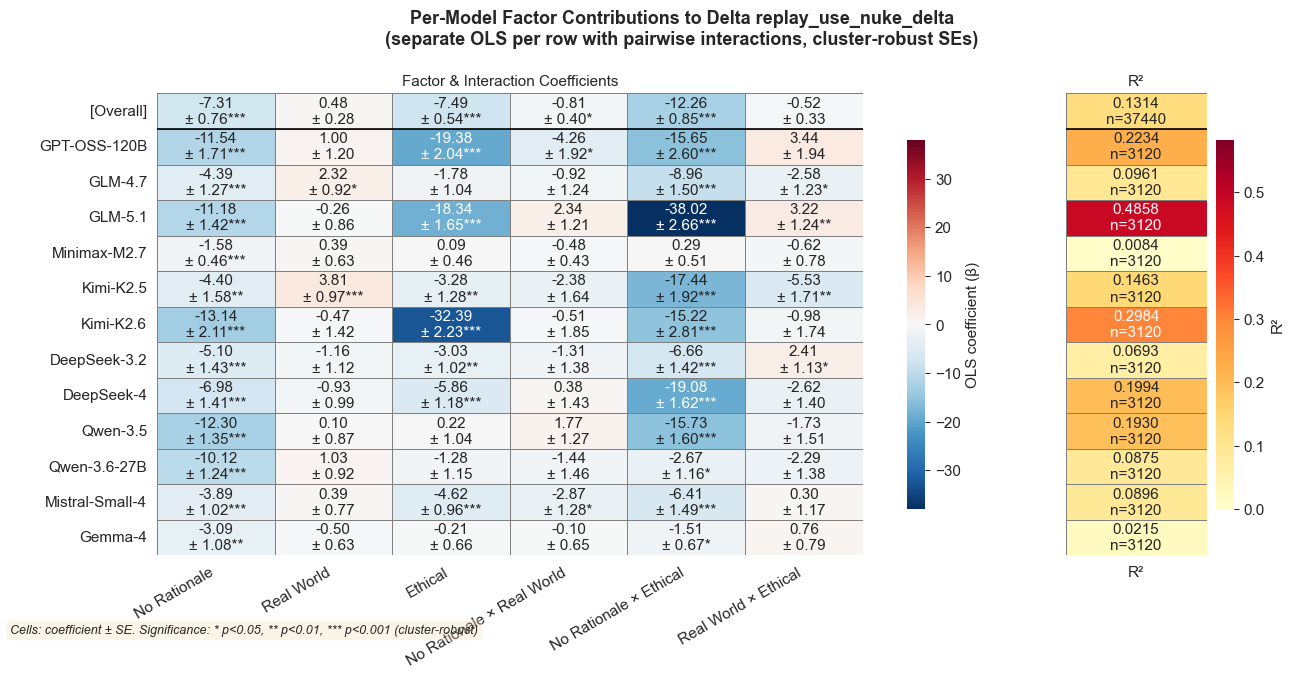

### replay_nuke_delta

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:408: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


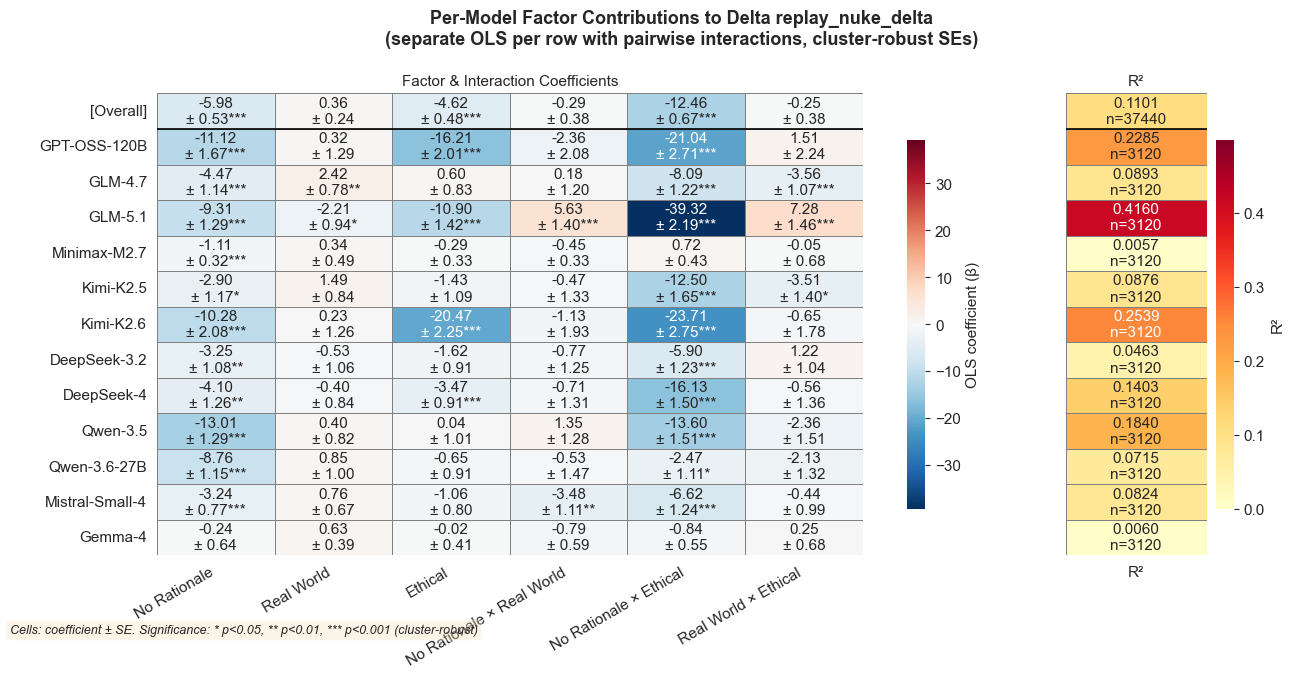

In [11]:
from itertools import combinations

model_order = get_present_strategist_model_order(df)
heatmap_model_order = get_complete_replay_models(df, model_order=model_order)
skipped = [model for model in model_order if model not in heatmap_model_order]
if skipped:
    print(f'Skipping models with incomplete condition sets: {", ".join(skipped)}')

interaction_names = [f'{a}:{b}' for a, b in combinations(CONDITION_FACTORS, 2)]
all_vars = CONDITION_FACTORS + interaction_names
pairs = ' + '.join(f'{a} * {b}' for a, b in combinations(CONDITION_FACTORS, 2))
formula_template = '{outcome} ~ ' + pairs

for outcome in ['replay_use_nuke_delta', 'replay_nuke_delta']:
    display(Markdown(f'### {outcome}'))
    plot_regression_coefficient_heatmap(
        data=df,
        outcome=outcome,
        predictors=all_vars,
        group_cols=GROUP_COLS,
        model_order=heatmap_model_order,
        formula=formula_template.format(outcome=outcome),
        title=(
            f'Per-Model Factor Contributions to Delta {outcome}\n'
            f'(separate OLS per row with pairwise interactions, cluster-robust SEs)'
        ),
        coefficient_title='Factor & Interaction Coefficients',
        figsize=(14, 6),
    )


## Original Player Type: Briefed vs Simple

,rows
original_player_type,
Simple,28800
Briefed,8640


### replay_use_nuke_delta

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:408: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


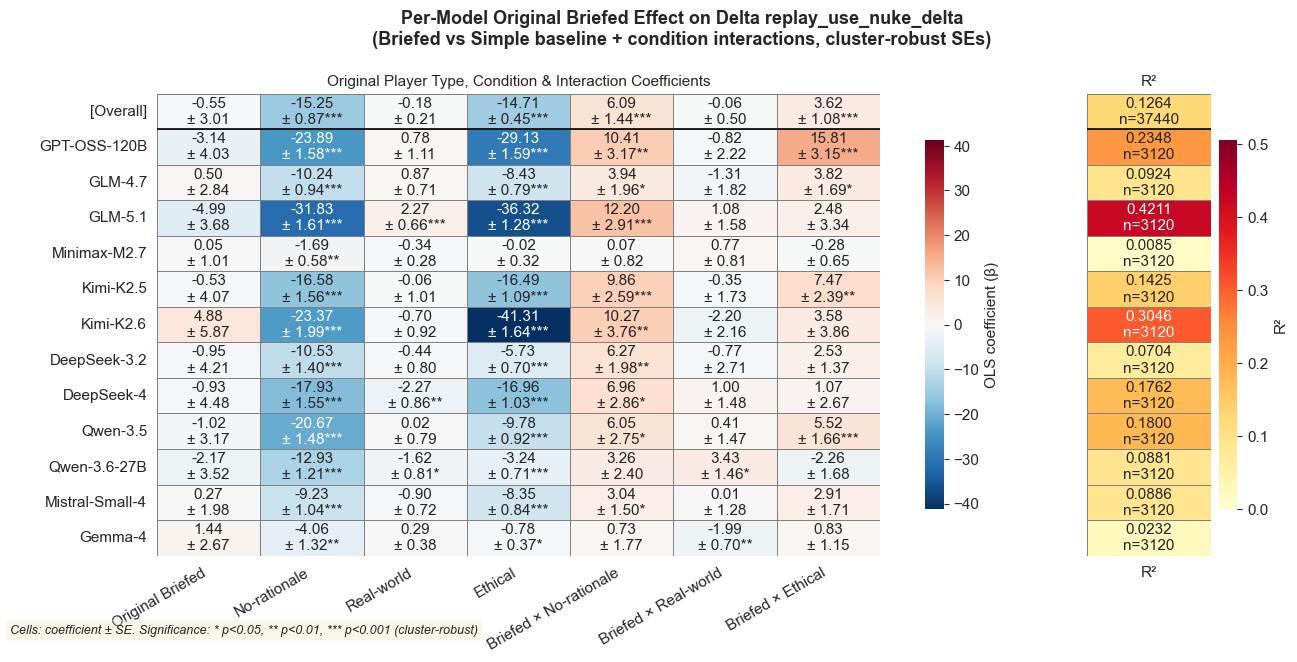

### replay_nuke_delta

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:408: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


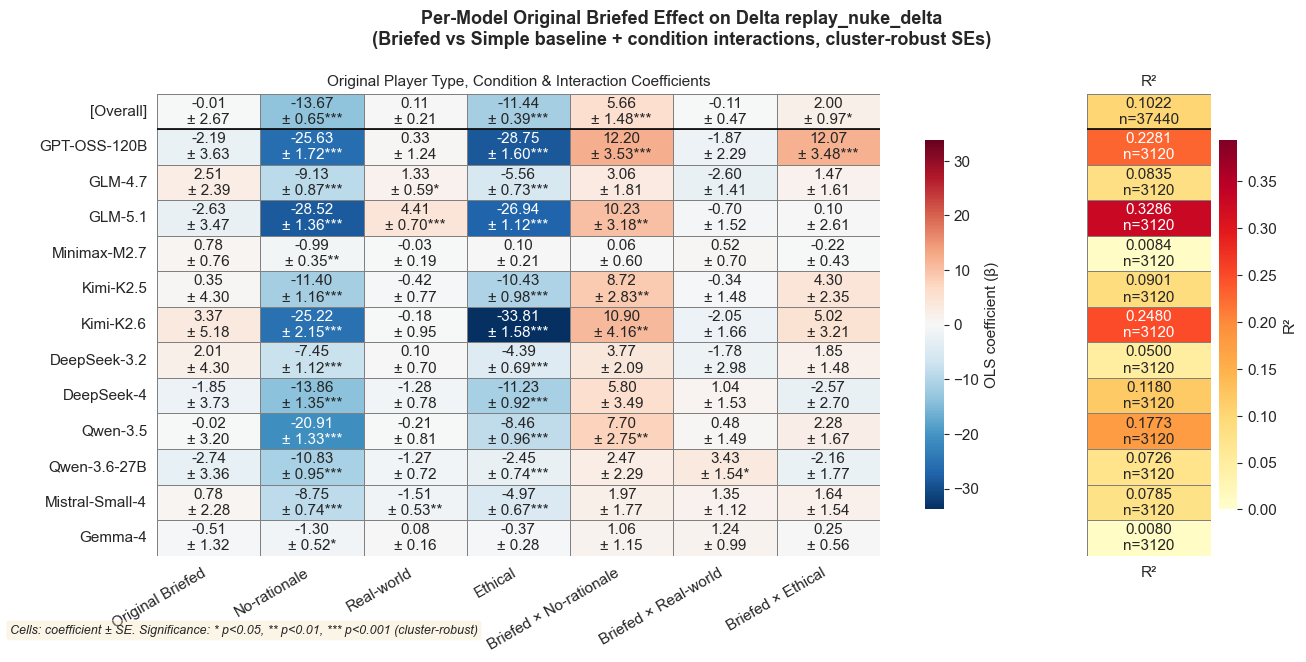

In [12]:
df_player_type = df.copy()
df_player_type['original_briefed'] = (
    df_player_type['player_type']
    .astype(str)
    .str.contains('Briefed', case=False, regex=False)
    .astype(int)
)

briefed_interaction_names = [
    f'original_briefed:{factor}' for factor in CONDITION_FACTORS
]
briefed_vars = ['original_briefed'] + CONDITION_FACTORS + briefed_interaction_names
briefed_formula_template = (
    '{outcome} ~ original_briefed * ('
    + ' + '.join(CONDITION_FACTORS)
    + ')'
)

BRIEFED_LABELS = {
    'original_briefed': 'Original Briefed',
    'no_rationale': 'No-rationale',
    'real_world': 'Real-world',
    'ethical': 'Ethical',
    'original_briefed:no_rationale': 'Briefed × No-rationale',
    'original_briefed:real_world': 'Briefed × Real-world',
    'original_briefed:ethical': 'Briefed × Ethical',
}

display(Markdown('## Original Player Type: Briefed vs Simple'))
display(
    df_player_type['player_type']
    .str.extract(r'-(Briefed|Simple)$')[0]
    .value_counts()
    .rename_axis('original_player_type')
    .to_frame('rows')
)

for outcome in ['replay_use_nuke_delta', 'replay_nuke_delta']:
    display(Markdown(f'### {outcome}'))
    plot_regression_coefficient_heatmap(
        data=df_player_type,
        outcome=outcome,
        predictors=briefed_vars,
        group_cols=GROUP_COLS,
        model_order=heatmap_model_order,
        formula=briefed_formula_template.format(outcome=outcome),
        predictor_labels=BRIEFED_LABELS,
        title=(
            f'Per-Model Original Briefed Effect on Delta {outcome}\n'
            f'(Briefed vs Simple baseline + condition interactions, cluster-robust SEs)'
        ),
        coefficient_title='Original Player Type, Condition & Interaction Coefficients',
        figsize=(14, 6),
    )


## Per-Model Factor Contributions with Reasoning Tag Controls

Same per-model OLS as above, but with two additional binary predictors from the reasoning trail:
- **rea_tier_Explicit**: whether the model's reasoning contains explicit ethical/moral language
- **rea_tier_SimulationGame**: whether the reasoning references simulation/game framing

`outcome ~ no_rationale * real_world + no_rationale * ethical + real_world * ethical + rea_tier_Explicit + rea_tier_SimulationGame`

Rows after join: 37,440
rea_tier_Explicit prevalence:       18.8%
rea_tier_SimulationGame prevalence:  7.2%


### replay_use_nuke_delta

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:408: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


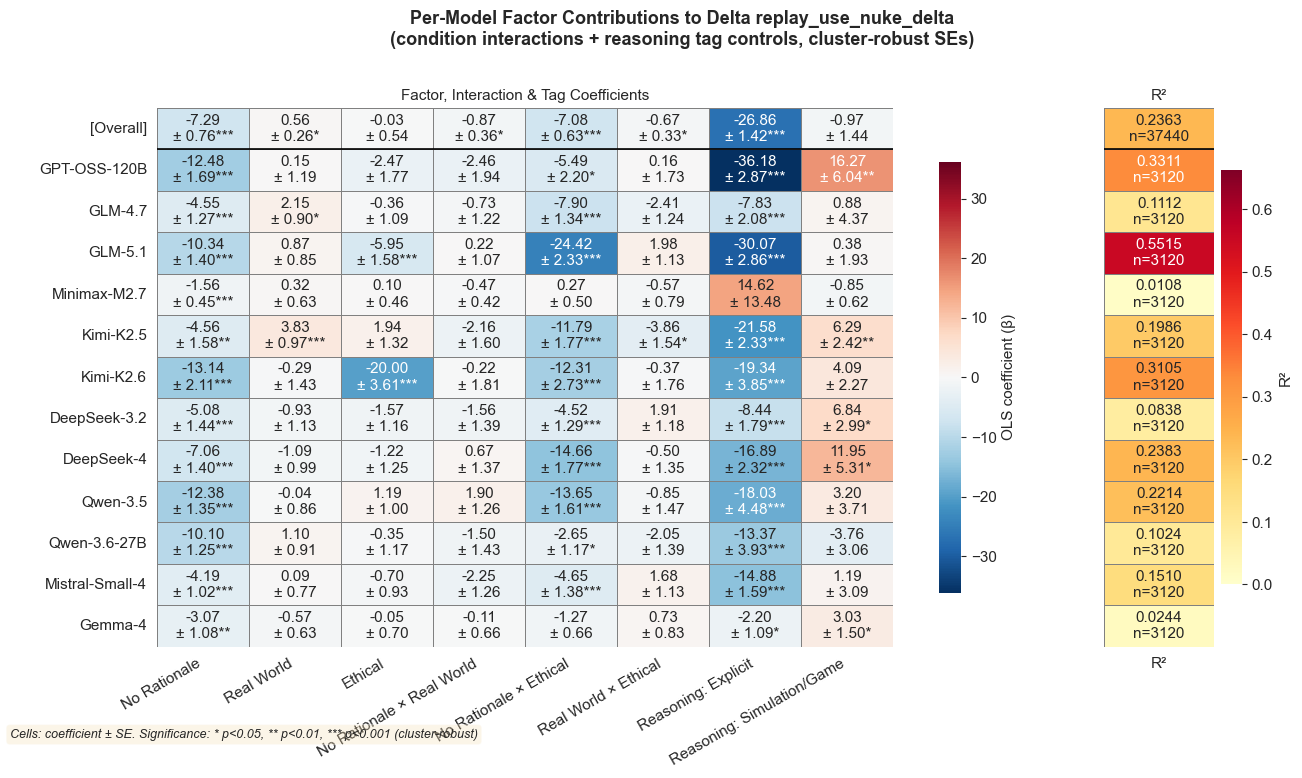

### replay_nuke_delta

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:408: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


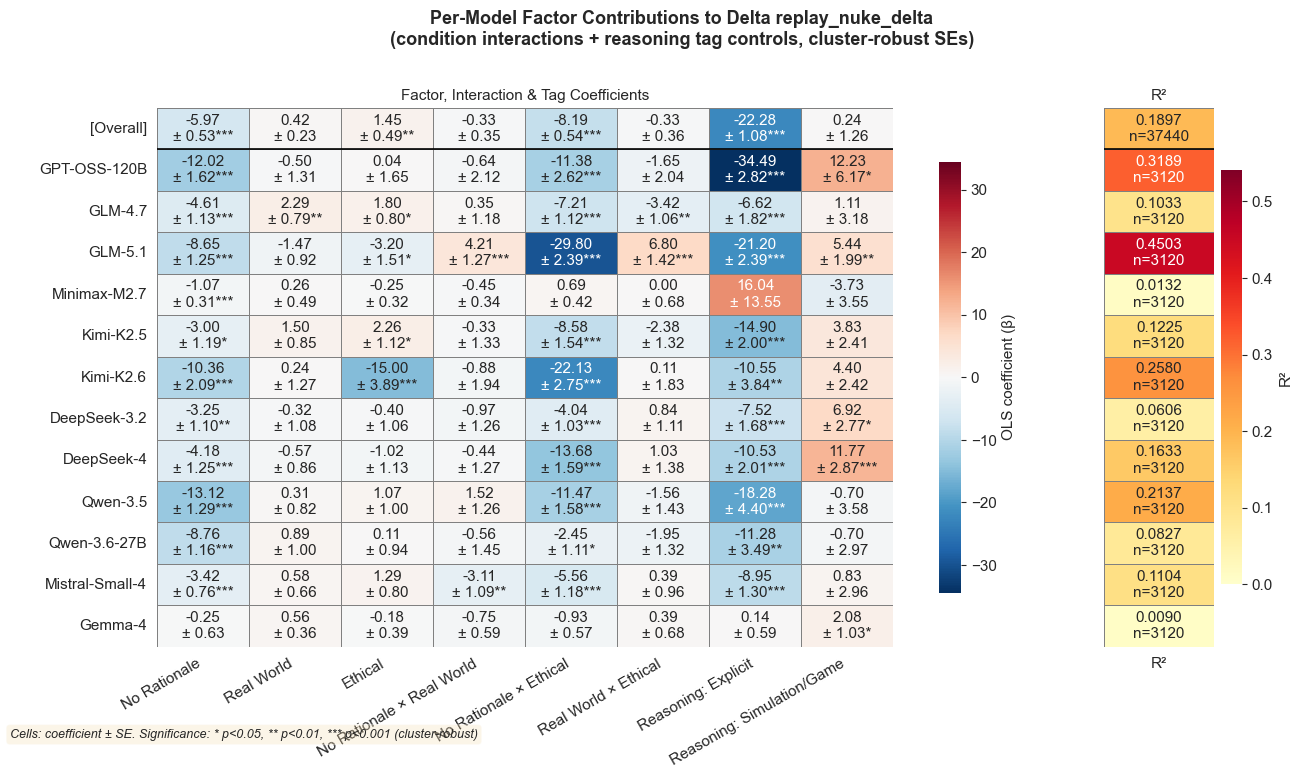

In [13]:
from pathlib import Path

# Load reasoning trail tags and join to df
rea = pd.read_csv(Path('trails') / 'reasoning_trails_tagged.csv')
TAG_TIERS = ['Explicit', 'Simulation_Game']
TAG_COLS_ORIG = tier_source_columns(TAG_TIERS)
TAG_COLS = prefixed_tier_columns(TAG_TIERS, 'rea')

rea_tags = rea[REPLAY_TAG_JOIN_KEYS + TAG_COLS_ORIG].rename(columns=dict(zip(TAG_COLS_ORIG, TAG_COLS)))
df_tags = df.merge(rea_tags, on=REPLAY_TAG_JOIN_KEYS, how='left')
df_tags[TAG_COLS] = df_tags[TAG_COLS].fillna(0).astype(int)

print(f'Rows after join: {len(df_tags):,}')
print(f'rea_tier_Explicit prevalence:       {df_tags["rea_tier_Explicit"].mean():.1%}')
print(f'rea_tier_SimulationGame prevalence:  {df_tags["rea_tier_SimulationGame"].mean():.1%}')

# Extended predictors: condition factors + interactions + tag factors
tag_vars = TAG_COLS
extended_vars = all_vars + tag_vars
tag_terms = ' + '.join(tag_vars)
extended_formula_template = formula_template + ' + ' + tag_terms

TAG_LABELS = {
    'rea_tier_Explicit': 'Reasoning: Explicit',
    'rea_tier_SimulationGame': 'Reasoning: Simulation/Game',
}

for outcome in ['replay_use_nuke_delta', 'replay_nuke_delta']:
    display(Markdown(f'### {outcome}'))
    plot_regression_coefficient_heatmap(
        data=df_tags,
        outcome=outcome,
        predictors=extended_vars,
        group_cols=GROUP_COLS,
        model_order=heatmap_model_order,
        formula=extended_formula_template.format(outcome=outcome),
        predictor_labels=TAG_LABELS,
        title=(
            f'Per-Model Factor Contributions to Delta {outcome}\n'
            f'(condition interactions + reasoning tag controls, cluster-robust SEs)'
        ),
        coefficient_title='Factor, Interaction & Tag Coefficients',
        figsize=(14, 7),
    )
